In [1]:
import pandas as pd
import statsmodels.api as sm
import numpy as np
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
from sklearn.linear_model import LinearRegression

In [2]:
spc = pd.read_csv(r"C:\Users\Username\OneDrive\Desktop\Invesco_project\data\^GSPC_mon.csv")
spe = pd.read_csv(r"C:\Users\Username\OneDrive\Desktop\Invesco_project\data\RSP_mon.csv", nrows =239)

In [3]:
spc["Date"] = pd.to_datetime(spc["Date"])
spe["Date"] = pd.to_datetime(spe["Date"])

In [4]:
spc.set_index("Date", inplace=True)
spe.set_index("Date", inplace=True)

In [5]:
spc

,Close,High,Low,Open,Volume
Date,,,,,
1985-01-01,179.630005,180.270004,163.360001,167.199997,2.673710e+09
1985-02-01,181.179993,183.949997,177.750000,179.630005,2.194620e+09
1985-03-01,180.660004,183.889999,176.529999,181.179993,2.153090e+09
1985-04-01,179.830002,183.610001,177.860001,180.660004,1.981880e+09
1985-05-01,189.550003,189.979996,178.350006,179.830002,2.350340e+09
...,...,...,...,...,...
2025-01-01,6040.529785,6128.180176,5773.310059,5903.259766,8.863938e+10
2025-02-01,5954.500000,6147.430176,5837.660156,5969.649902,9.231700e+10
2025-03-01,5611.850098,5986.089844,5488.729980,5968.330078,1.113870e+11


In [6]:
spc.index = spc.index + pd.tseries.offsets.MonthEnd(0)

spc['mkt_ret'] = spc['Close'].pct_change()
mkt_ret = spc[['mkt_ret']].dropna().copy()

mkt_ret

,mkt_ret
Date,
1985-02-28,0.008629
1985-03-31,-0.002870
1985-04-30,-0.004594
1985-05-31,0.054051
1985-06-30,0.012134
...,...
2025-01-31,0.027016
2025-02-28,-0.014242
2025-03-31,-0.057545


In [7]:
sp = pd.read_csv(r"C:\Users\Username\OneDrive\Desktop\Invesco_project\sp500_returns_with_tickers.csv")
sp

,date,ACF,ABK,AMT,JAVA,AN,ORCL,MSFT,SDS,AYE,...,CFN,AVGO,VRSK,DG.2,FTNT,VAL,GNRC,QEP,CBOE,TSLA
0,1960-01-29,0.005155,-0.015000,-0.020785,NaN,-0.092262,NaN,NaN,NaN,-0.020833,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1960-02-29,0.046154,0.017767,0.009434,NaN,-0.021312,NaN,NaN,NaN,0.053192,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1960-03-31,-0.059553,-0.100249,-0.047170,NaN,0.038851,NaN,NaN,NaN,-0.005387,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1960-04-29,-0.081794,-0.056180,0.000000,NaN,-0.050407,NaN,NaN,NaN,0.010274,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1960-05-31,0.048851,-0.029762,-0.034654,NaN,0.029110,NaN,NaN,NaN,0.044068,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
775,2024-08-30,NaN,NaN,NaN,NaN,NaN,0.013195,-0.001100,NaN,NaN,...,NaN,0.013319,0.042292,-0.310823,0.321675,NaN,0.005460,NaN,0.122718,-0.077391
776,2024-09-30,NaN,NaN,NaN,NaN,NaN,0.206030,0.031548,NaN,NaN,...,NaN,0.062707,-0.016385,0.019284,0.010950,NaN,0.015013,NaN,-0.002580,0.221942
777,2024-10-31,NaN,NaN,NaN,NaN,NaN,-0.012676,-0.055659,NaN,NaN,...,NaN,-0.015826,0.025228,-0.046589,0.014313,NaN,0.041981,NaN,0.042466,-0.045025
778,2024-11-29,NaN,NaN,NaN,NaN,NaN,0.101287,0.044149,NaN,NaN,...,NaN,-0.045297,0.070945,-0.034608,0.208365,NaN,0.136817,NaN,0.013626,0.381469


In [8]:
sp['date'] = pd.to_datetime(sp['date'])
sp.set_index('date', inplace=True)

In [9]:
data = sp.join(mkt_ret, how='inner')
data

,ACF,ABK,AMT,JAVA,AN,ORCL,MSFT,SDS,AYE,TROW,...,AVGO,VRSK,DG.2,FTNT,VAL,GNRC,QEP,CBOE,TSLA,mkt_ret
1985-02-28,NaN,NaN,-0.013423,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.008629
1985-04-30,NaN,NaN,-0.058065,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.004594
1985-05-31,NaN,NaN,-0.008621,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.054051
1985-07-31,NaN,NaN,-0.060741,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.004848
1985-09-30,NaN,NaN,-0.079646,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.034724
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-05-31,NaN,NaN,NaN,NaN,NaN,0.030242,0.068194,NaN,NaN,0.075386,...,0.021749,0.159754,-0.016381,-0.061095,NaN,0.082745,NaN,-0.042009,-0.028372,0.048021
2024-07-31,NaN,NaN,NaN,NaN,NaN,-0.009561,-0.063989,NaN,NaN,-0.009539,...,0.000791,-0.028937,-0.085079,-0.037000,NaN,0.177431,NaN,0.079090,0.172781,0.011321
2024-09-30,NaN,NaN,NaN,NaN,NaN,0.206030,0.031548,NaN,NaN,0.038948,...,0.062707,-0.016385,0.019284,0.010950,NaN,0.015013,NaN,-0.002580,0.221942,0.020197
2024-10-31,NaN,NaN,NaN,NaN,NaN,-0.012676,-0.055659,NaN,NaN,0.008538,...,-0.015826,0.025228,-0.046589,0.014313,NaN,0.041981,NaN,0.042466,-0.045025,-0.009897


## 36 month

In [10]:
window = 36

In [11]:
stock_returns = data.drop(columns=['mkt_ret'])
market_returns = data['mkt_ret']

In [12]:
beta_df = pd.DataFrame(index=stock_returns.index, columns=stock_returns.columns)

In [13]:
for i in range(window, len(stock_returns)):
    date = stock_returns.index[i]
    window_stock = stock_returns.iloc[i-window:i]
    window_market = market_returns.iloc[i-window:i]

    for col in stock_returns.columns:
        y = window_stock[col]
        x = window_market

        if y.isnull().any() or x.isnull().any():
            continue
        
        X = sm.add_constant(x.values)
        model = sm.OLS(y.values, X).fit()
        beta_df.loc[date, col] = model.params[1]

In [14]:
inv_beta_df = 1 / beta_df.astype(float)
inv_beta_df.replace([np.inf, -np.inf], np.nan, inplace=True)

## PF = low_inver_beta - high_inver_beta

In [15]:
# 1. 当前方向（long low inv_beta, short high inv_beta）
pf_invbeta_low_high = []
pf_invbeta_high_low = []

for i in range(window, len(stock_returns)):
    date = stock_returns.index[i]
    this_inv_beta = inv_beta_df.loc[date].dropna()

    if len(this_inv_beta) < 20:
        pf_invbeta_low_high.append(np.nan)
        pf_invbeta_high_low.append(np.nan)
        continue

    top = this_inv_beta.nlargest(int(len(this_inv_beta) * 0.2)).index  # high inv_beta = low beta
    bottom = this_inv_beta.nsmallest(int(len(this_inv_beta) * 0.2)).index  # low inv_beta = high beta

    long_ret = stock_returns.loc[date, top].mean()
    short_ret = stock_returns.loc[date, bottom].mean()

    pf_invbeta_low_high.append(long_ret - short_ret)   # PF1: low - high
    pf_invbeta_high_low.append(short_ret - long_ret)   # PF2: high - low

# 转为时间序列
index_slice = stock_returns.index[window:]
pf1 = pd.Series(pf_invbeta_low_high, index=index_slice)
pf2 = pd.Series(pf_invbeta_high_low, index=index_slice)
mkt = data['mkt_ret'].loc[index_slice]

# 计算 cumulative log return
pf1_cum = np.log1p(pf1.dropna()).cumsum()
pf2_cum = np.log1p(pf2.dropna()).cumsum()
mkt_cum = np.log1p(mkt.dropna()).cumsum()


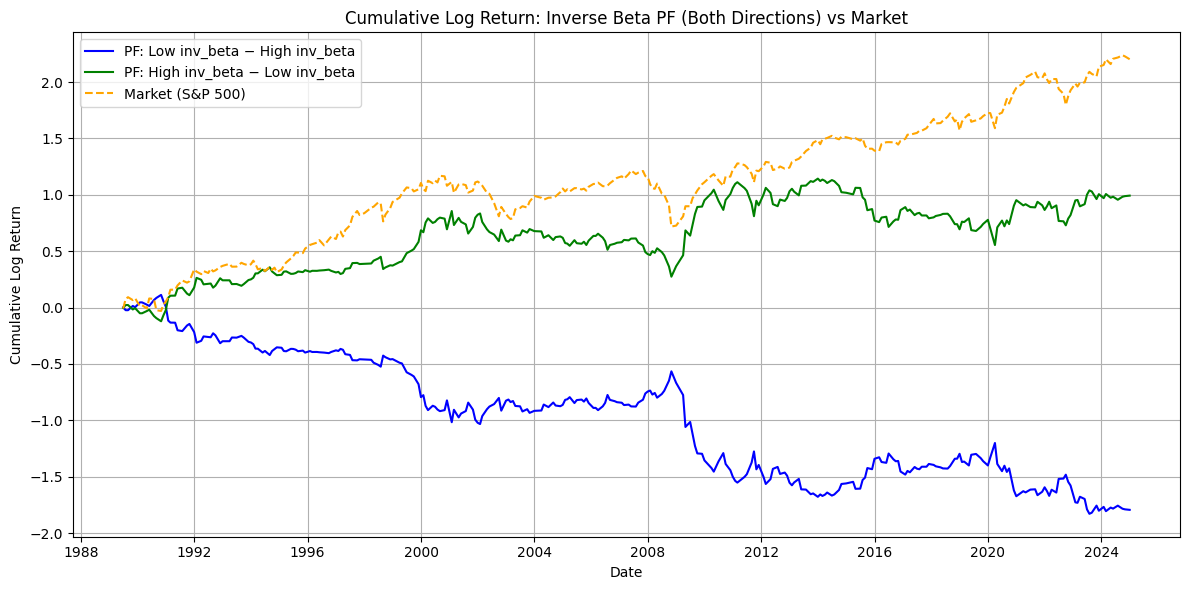

In [17]:
plt.figure(figsize=(12, 6))
plt.plot(pf1_cum, label="PF: Low inv_beta − High inv_beta", color='blue')
plt.plot(pf2_cum, label="PF: High inv_beta − Low inv_beta", color='green')
plt.plot(mkt_cum, label="Market (S&P 500)", linestyle='--', color='orange')
plt.title("Cumulative Log Return: Inverse Beta PF (Both Directions) vs Market")
plt.xlabel("Date")
plt.ylabel("Cumulative Log Return")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


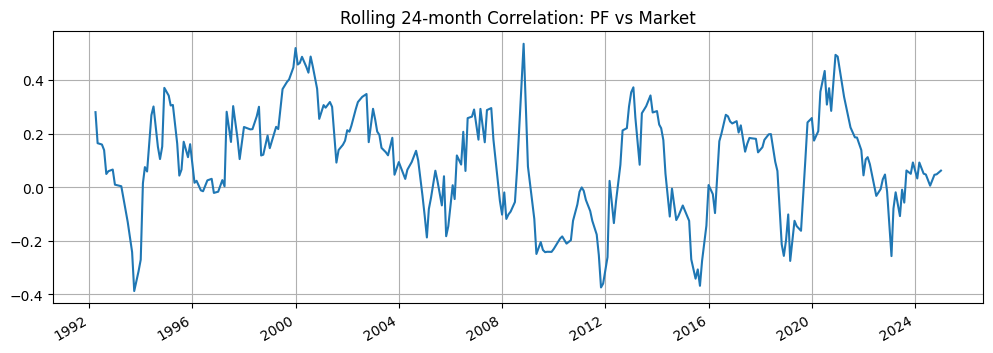

In [18]:
rolling_corr = pf2.rolling(24).corr(mkt_cum)
rolling_corr.plot(figsize=(12, 4), title="Rolling 24-month Correlation: PF vs Market")
plt.grid(True)


In [19]:
ff5 = pd.read_csv(r"C:\Users\Username\OneDrive\Desktop\Invesco_project\F-F_Research_Data_5_Factors_2x3.csv", skiprows =3, nrows =742)
ff5

,Unnamed: 0,Mkt-RF,SMB,HML,RMW,CMA,RF
0,196307,-0.39,-0.48,-0.81,0.64,-1.15,0.27
1,196308,5.08,-0.80,1.70,0.40,-0.38,0.25
2,196309,-1.57,-0.43,0.00,-0.78,0.15,0.27
3,196310,2.54,-1.34,-0.04,2.79,-2.25,0.29
4,196311,-0.86,-0.85,1.73,-0.43,2.27,0.27
...,...,...,...,...,...,...,...
737,202412,-3.15,-3.84,-3.00,1.91,-1.21,0.37
738,202501,2.80,-1.22,1.62,-2.33,-3.24,0.37
739,202502,-2.43,-4.93,4.91,1.09,3.06,0.33
740,202503,-6.39,-1.49,2.90,2.11,-0.47,0.34


In [20]:
ff5.rename(columns={"Unnamed: 0": "Date"}, inplace=True)

ff5["Date"] = pd.to_datetime(ff5["Date"], format="%Y%m")

ff5.set_index("Date", inplace=True)

ff5 = ff5.astype(float) / 100
ff5

,Mkt-RF,SMB,HML,RMW,CMA,RF
Date,,,,,,
1963-07-01,-0.0039,-0.0048,-0.0081,0.0064,-0.0115,0.0027
1963-08-01,0.0508,-0.0080,0.0170,0.0040,-0.0038,0.0025
1963-09-01,-0.0157,-0.0043,0.0000,-0.0078,0.0015,0.0027
1963-10-01,0.0254,-0.0134,-0.0004,0.0279,-0.0225,0.0029
1963-11-01,-0.0086,-0.0085,0.0173,-0.0043,0.0227,0.0027
...,...,...,...,...,...,...
2024-12-01,-0.0315,-0.0384,-0.0300,0.0191,-0.0121,0.0037
2025-01-01,0.0280,-0.0122,0.0162,-0.0233,-0.0324,0.0037
2025-02-01,-0.0243,-0.0493,0.0491,0.0109,0.0306,0.0033


In [21]:
ffm = pd.read_csv(r"C:\Users\Username\OneDrive\Desktop\Invesco_project\F-F_Momentum_Factor.csv",skiprows= 13, nrows = 1180)

In [22]:
ffm.rename(columns={"Unnamed: 0": "Date"}, inplace=True)

ffm["Date"] = pd.to_datetime(ffm["Date"], format="%Y%m")

ffm.set_index("Date", inplace=True)

ffm = ffm.astype(float) / 100

ff = ff5.join(ffm, how="inner")
ff

,Mkt-RF,SMB,HML,RMW,CMA,RF,Mom
Date,,,,,,,
1963-07-01,-0.0039,-0.0048,-0.0081,0.0064,-0.0115,0.0027,0.0101
1963-08-01,0.0508,-0.0080,0.0170,0.0040,-0.0038,0.0025,0.0100
1963-09-01,-0.0157,-0.0043,0.0000,-0.0078,0.0015,0.0027,0.0012
1963-10-01,0.0254,-0.0134,-0.0004,0.0279,-0.0225,0.0029,0.0313
1963-11-01,-0.0086,-0.0085,0.0173,-0.0043,0.0227,0.0027,-0.0078
...,...,...,...,...,...,...,...
2024-12-01,-0.0315,-0.0384,-0.0300,0.0191,-0.0121,0.0037,-0.0030
2025-01-01,0.0280,-0.0122,0.0162,-0.0233,-0.0324,0.0037,0.0095
2025-02-01,-0.0243,-0.0493,0.0491,0.0109,0.0306,0.0033,-0.0082


In [23]:
ff.index = ff.index + pd.tseries.offsets.MonthEnd(0)
ff = ff.loc["1985-02":"2024-12"]
ff

,Mkt-RF,SMB,HML,RMW,CMA,RF,Mom
Date,,,,,,,
1985-02-28,0.0122,0.0091,-0.0036,0.0152,0.0116,0.0058,0.0190
1985-03-31,-0.0084,-0.0138,0.0401,0.0123,0.0286,0.0062,0.0178
1985-04-30,-0.0096,-0.0014,0.0360,0.0162,0.0071,0.0072,0.0295
1985-05-31,0.0507,-0.0236,-0.0098,0.0127,-0.0143,0.0066,0.0405
1985-06-30,0.0127,0.0021,0.0038,0.0169,-0.0102,0.0055,0.0337
...,...,...,...,...,...,...,...
2024-08-31,0.0161,-0.0356,-0.0110,0.0073,0.0082,0.0048,0.0477
2024-09-30,0.0173,-0.0091,-0.0277,0.0018,-0.0029,0.0040,-0.0059
2024-10-31,-0.0100,-0.0088,0.0086,-0.0140,0.0098,0.0039,0.0298


In [25]:
pf2.index = pf2.index.to_period("M").to_timestamp("M")
ff.index = ff.index.to_period("M").to_timestamp("M")

In [29]:
pf_excess = pf2 - ff["RF"]

X = ff[["Mkt-RF", "SMB", "HML", "RMW", "CMA", "Mom"]]
X = sm.add_constant(X)

reg_df = pd.concat([pf_excess.rename("y"), X], axis=1).dropna()

y = reg_df["y"]
X_clean = reg_df.drop(columns="y")

model = sm.OLS(y, X_clean).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.639
Model:                            OLS   Adj. R-squared:                  0.632
Method:                 Least Squares   F-statistic:                     86.59
Date:                Mon, 21 Jul 2025   Prob (F-statistic):           5.73e-62
Time:                        07:52:37   Log-Likelihood:                 618.24
No. Observations:                 300   AIC:                            -1222.
Df Residuals:                     293   BIC:                            -1197.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0002      0.002      0.116      0.9

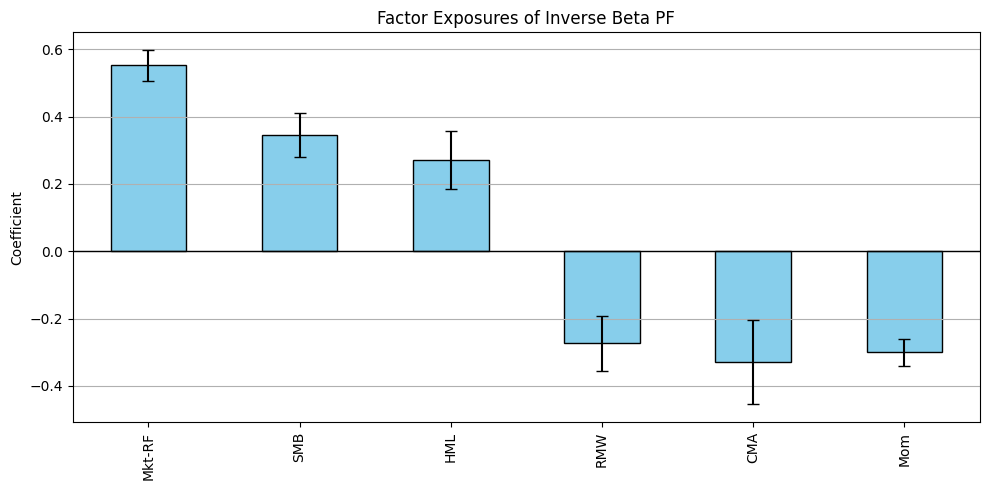

In [27]:
coefs = model.params.drop('const')
errors = model.bse.drop('const')

plt.figure(figsize=(10, 5))
coefs.plot(kind='bar', yerr=errors, capsize=4, color='skyblue', edgecolor='black')
plt.axhline(0, color='black', linewidth=1)
plt.title("Factor Exposures of Inverse Beta PF")
plt.ylabel("Coefficient")
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()

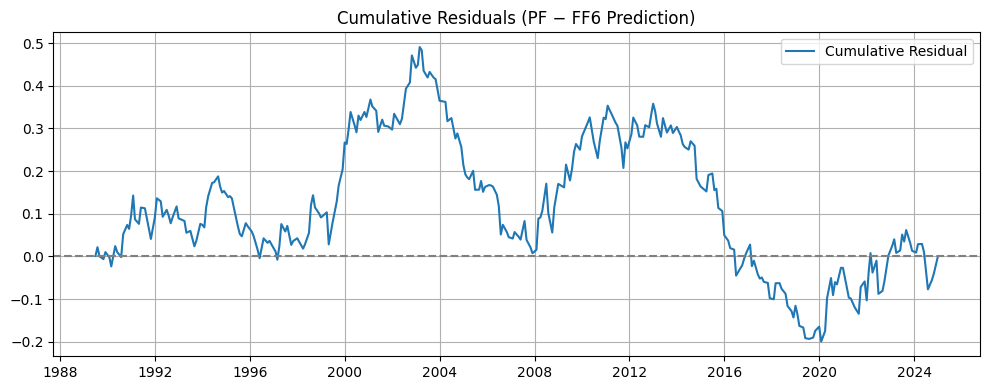

In [28]:
resid_cum = model.resid.cumsum()

plt.figure(figsize=(10, 4))
plt.plot(resid_cum, label="Cumulative Residual")
plt.axhline(0, color='gray', linestyle='--')
plt.title("Cumulative Residuals (PF − FF6 Prediction)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


In [30]:
window = 36
rolling_betas = {col: [] for col in reg_df.columns if col != "y"}
rolling_dates = []

for i in range(window, len(reg_df)):
    window_df = reg_df.iloc[i-window:i]
    y_win = window_df["y"]
    X_win = window_df.drop(columns="y")

    model = sm.OLS(y_win, X_win).fit()
    for col in X_win.columns:
        rolling_betas[col].append(model.params[col])
    rolling_dates.append(reg_df.index[i])

rolling_betas_df = pd.DataFrame(rolling_betas, index=rolling_dates)

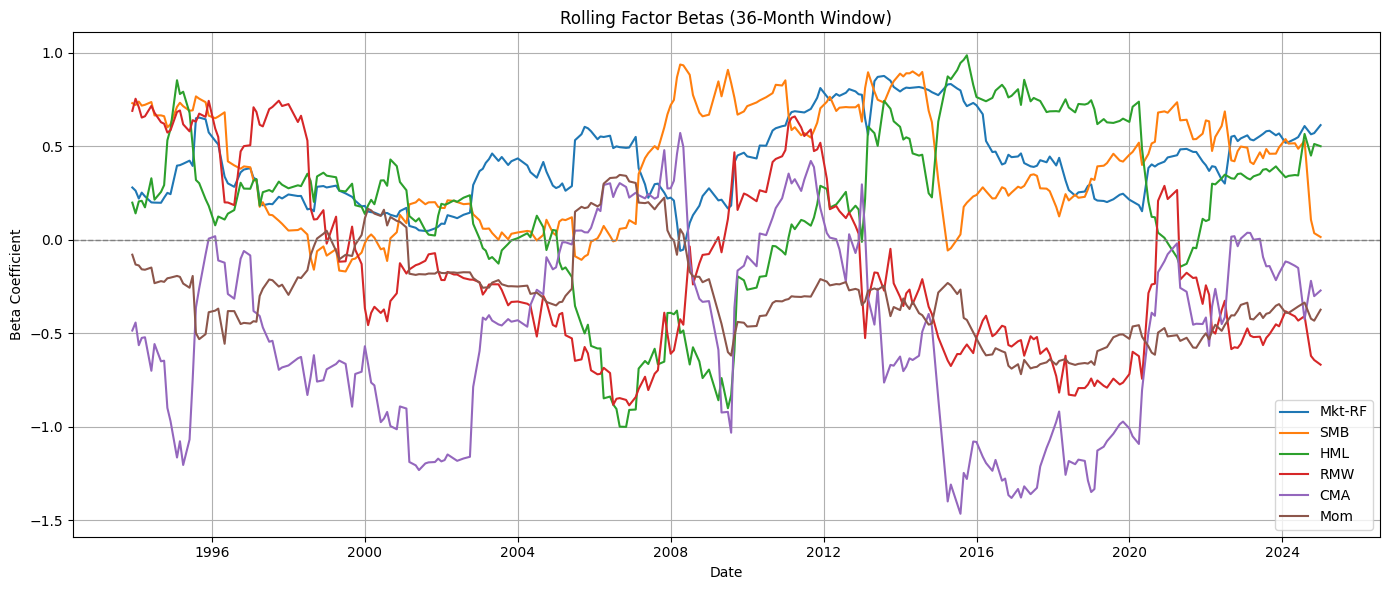

In [32]:
plt.figure(figsize=(14, 6))
for col in rolling_betas_df.columns:
    if col != "const":
        plt.plot(rolling_betas_df.index, rolling_betas_df[col], label=col)
plt.axhline(0, color='gray', linestyle='--', linewidth=1)
plt.title("Rolling Factor Betas (36-Month Window)")
plt.ylabel("Beta Coefficient")
plt.xlabel("Date")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()